# 1. Setup and load data

## 1.1 Load Dependencies

In [ ]:
import os, random, shutil
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import kagglehub
import cv2
import matplotlib.pyplot as plt
import numpy as np
import copy
from torch.utils.data import Dataset, DataLoader, Subset, random_split

## 1.2 Select Backend

In [2]:
# Select torch backend device based on availability
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("torch:", torch.__version__)
print("device:", device)

torch: 2.13.0+cu132
device: cuda


## 1.3 Load foood dataset

In [ ]:
import requests, tarfile
from pathlib import Path
def download_food_dataset():
    url = "https://data.vision.ee.ethz.ch/cvl/food-101.tar.gz"
    docs = Path.home() / "Documents"
    images = docs / "food-101" / "images"
    if images.is_dir():
        print('dataset found')
        return str(images)

    tgz = Path.home() / "Downloads" / "food-101.tar.gz"
    if not tgz.exists():
        print("downloading", url)
        response = requests.get(url, stream=True)
        response.raise_for_status()
        # get total length of file
        total = int(response.headers["Content-Length"])
        # give our downloading folder a temp name while ongoing
        part = tgz.parent / (tgz.name + ".part")
        done = 0
        with open(part, "wb") as f:
            # download content slowly, otherwise entirety of dataset gets stuffed in ram
            for chunk in response.iter_content(chunk_size= 10 * 1024 * 1024):   # 10 MB at a time
                f.write(chunk)
                done += len(chunk)
                print(f"\r  {100 * done / total:.1f}%", end="")
        part.rename(tgz)          # only becomes the real file once complete
        print()

    print("extracting to", docs)
    with tarfile.open(tgz, "r:gz") as tar:
        tar.extractall(path=docs)
    return str(images)

def load_official_split(dataset, images_path, val_fraction=0.1, seed=42):
    """Map Food-101's official train/test lists onto dataset indices.

    meta/train.txt and meta/test.txt hold lines like 'apple_pie/1005649'
    (no extension). The 250 test images per class were manually reviewed;
    the 750 training ones were deliberately left noisy, so the two must not
    be mixed. Validation is carved out of train, leaving test untouched.
    """
    meta_folder = Path(images_path).parent / "meta"

    # Step 1 -- build a lookup so a line of text can become a dataset position.
    #           "apple_pie/1005649"  ->  17423
    lookup = {}
    for position in range(len(dataset)):
        class_index = int(dataset.targets[position])
        class_name = dataset.classes[class_index]
        # turn numpy byte array back into a string
        filename = dataset.fnames[position].decode()   # "1005649.jpg"
        image_id = filename.removesuffix(".jpg")       # "1005649"
        lookup[class_name + "/" + image_id] = position

    # Step 2 -- turn a meta file into an array of dataset positions.
    def read_list(name):
        positions = []
        with open(meta_folder / name) as f:
            for line in f:
                line = line.strip()
                if line:
                    positions.append(lookup[line])     # KeyError = lists disagree
        return np.array(positions, dtype=np.int32)

    train_and_val = read_list("train.txt")
    test = read_list("test.txt")

    # Step 3 -- shuffle the training list, slice a validation chunk off the front.
    shuffled = np.random.default_rng(seed).permutation(train_and_val)
    val_size = int(len(shuffled) * val_fraction)
    val = shuffled[:val_size]
    train = shuffled[val_size:]

    print(f"train {len(train)} | val {len(val)} | test {len(test)}")
    return train, val, test

def pre_resize_dataset():
    """
    Write a parallel, resized dataset where every image has its shortest side at 256px. 
    """
    old_path   = Path.home() / "Documents" / "food-101" / "images"
    final_root = Path.home() / "Documents" / "food-101-256"
    new_path   = final_root / "images"

    if new_path.is_dir():
        print("scaled dataset found")
        return str(new_path)

    # Build into a .tmp directory and rename at the very end, so an interrupted
    # run never leaves a half-converted tree that the check above would accept.
    tmp_root = final_root.with_name(final_root.name + ".tmp") # becomes ./food-101-256.tmp for now
    if tmp_root.exists():
        shutil.rmtree(tmp_root)                     # discard a previous failed attempt

    tmp_images = tmp_root / "images"
    tmp_images.mkdir(parents=True)
    shutil.copytree(old_path.parent / "meta", tmp_root / "meta")
    classes = sorted(d.name for d in os.scandir(old_path) if d.is_dir())

    for i, class_name in enumerate(classes, 1):
        src_dir = old_path / class_name
        dest_dir = tmp_images / class_name
        dest_dir.mkdir(parents=True, exist_ok=True)

        for image in src_dir.iterdir():
            with Image.open(image) as im:
                w, h = im.size
                scale = 256 / min(w, h)
                if scale >=1:
                    # copy2 to preserve file metadata
                    shutil.copy2(image, dest_dir / image.name)
                    continue
                new_size = (round(w * scale), round(h*scale))
                img = im.convert('RGB')
                img = img.resize(new_size, Image.LANCZOS)
                img.save(dest_dir / image.name, quality = 95)
        print(f"\r  {i}/{len(classes)}  {class_name:<25}", end="")
    print()

    tmp_root.rename(final_root)
    return str(new_path)

In [ ]:
download_food_dataset()
path = pre_resize_dataset()
print("Path to dataset files:", path)

dataset found
Path to dataset files: C:\Users\nimav\Documents\food-101\images


1. Set the number of classes to 100 (for now)
2. Normalize pixel values of input images
3. Perform transformations so the model can't memorize exact pictures.
4. Create dataset & training-specific dataset and transform training dataset

# 2. Preprocess Data

`ToTensor()` already scales PIL images to tensor, so we don't need to perform manual scaling. Let's move to train-test-validation split.

1. Pick Images & Train-Test Split

In [5]:
from torch.utils.data import Dataset
from PIL import Image

class CompactImageFolder(Dataset):
    """ImageFolder that pickles in ~6 MB instead of ~200 MB.

    Paths are root/class/NNN.jpg, so only the filename and label need storing.
    Keeping them as numpy buffers means Windows worker spawn copies raw bytes
    instead of millions of Python str/tuple objects.
    """
    def __init__(self, root, transform=None):
        self.root, self.transform = root, transform
        self.classes = sorted(d.name for d in os.scandir(root) if d.is_dir())
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        fnames, targets = [], []
        for i, c in enumerate(self.classes):
            for e in sorted(os.scandir(os.path.join(root, c)), key=lambda e: e.name):
                if e.is_file() and e.name.lower().endswith(".jpg"):
                    fnames.append(e.name)
                    targets.append(i)
        self.fnames  = np.array(fnames, dtype='S16')
        self.targets = np.array(targets, dtype=np.int16)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, i):
        t = int(self.targets[i])
        p = os.path.join(self.root, self.classes[t], self.fnames[i].decode())
        img = Image.open(p).convert("RGB")
        return (self.transform(img) if self.transform else img), t


In [6]:
dataset = CompactImageFolder(root=path, transform=transforms.ToTensor())
tr_idx, va_idx, te_idx = load_official_split(dataset, path)

train 68175 | val 7575 | test 25250


2. Measure Mean/STD for Normalization (do not run unless needed)

In [7]:
# Run ONCE to produce the MEAN/STD in cell 10. Re-run only if NUM_CLASSES or
# either seed changes. Builds its own un-normalised copy on purpose.
stat_tfm = transforms.Compose([transforms.Resize(256),
                               transforms.CenterCrop(224),
                               transforms.ToTensor()])
raw = CompactImageFolder(root=path, transform=stat_tfm)


stat_loader = DataLoader(Subset(raw, tr_idx), batch_size=256, num_workers=0)
channel_sum, channel_sq_sum, count = torch.zeros(3), torch.zeros(3), 0
for images, _ in stat_loader:
    b = images.shape[0]
    pixels = images.view(b, 3, -1)          # (b,3,H,W) -> (b,3,H*W)
    channel_sum    += pixels.mean(2).sum(0)
    channel_sq_sum += (pixels ** 2).mean(2).sum(0)
    count          += b
mean = channel_sum / count
std  = (channel_sq_sum / count - mean ** 2).sqrt()   # sqrt(E[x^2] - E[x]^2)
print("MEAN =", [round(v, 4) for v in mean.tolist()])
print("STD  =", [round(v, 4) for v in std.tolist()])

MEAN = [0.5576, 0.4423, 0.327]
STD  = [0.2591, 0.263, 0.2656]


3. Transform + load data

In [8]:
# per-channel stats of all 101,100 training images; see the stats cell below
MEAN = [0.5576, 0.4423, 0.327]
STD  = [0.2591, 0.263, 0.2656]

train_tfm = transforms.Compose([transforms.RandomResizedCrop(224, scale=(0.5, 1.0)),
                                transforms.RandomHorizontalFlip(),
                                transforms.ToTensor(),
                                transforms.Normalize(MEAN, STD)])
eval_tfm  = transforms.Compose([transforms.Resize(256),
                                transforms.CenterCrop(224),
                                transforms.ToTensor(),
                                transforms.Normalize(MEAN, STD)])


dataset.transform = eval_tfm
train_dataset = copy.copy(dataset)          # same files, augmented transform
train_dataset.transform = train_tfm

pin = (device.type == 'cuda')  # pin memory only for GPU
train_loader = DataLoader(Subset(train_dataset, tr_idx), batch_size=128,
                          shuffle=True,  num_workers=0, pin_memory=pin)
val_loader   = DataLoader(Subset(dataset, va_idx), batch_size=256,
                          shuffle=False, num_workers=0, pin_memory=pin)
test_loader  = DataLoader(Subset(dataset, te_idx), batch_size=256,
                          shuffle=False, num_workers=0, pin_memory=pin)

Display subset of a batch to confirm data was successfully loaded

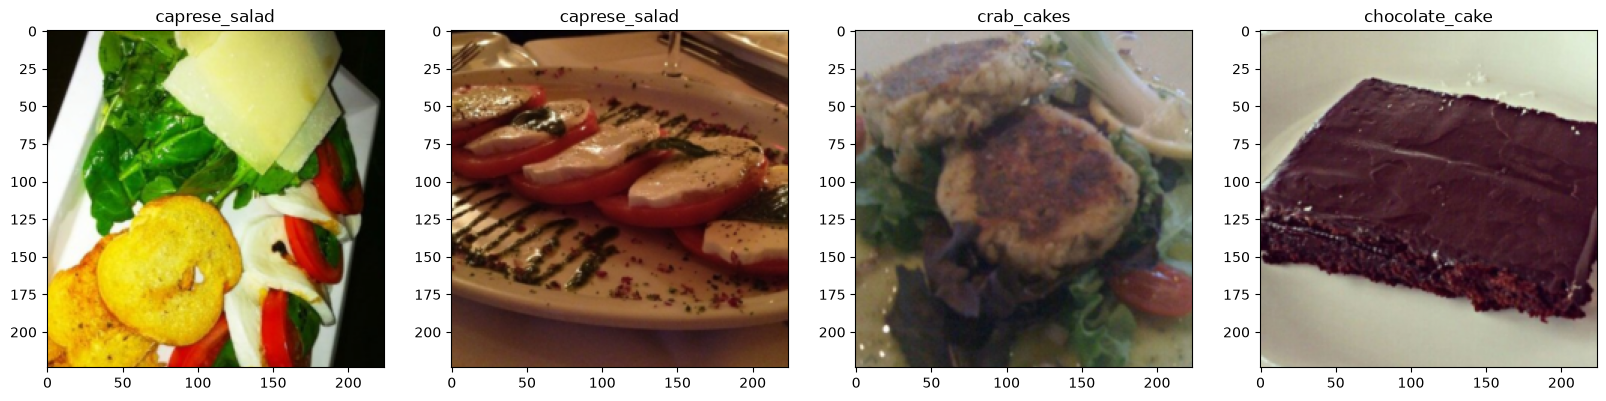

In [9]:
dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)
data_iterator = iter(dataloader)
batch = next(data_iterator)

fig, ax = plt.subplots(ncols=4, figsize=(20, 20))
for idx, img in enumerate(batch[0][:4]):
    image = img.permute(1, 2, 0).numpy()
    image = (image * np.array(STD) + np.array(MEAN)).clip(0, 1)  # unnormalize
    ax[idx].imshow(image)
    label = dataset.classes[batch[1][idx]]
    ax[idx].title.set_text(label)

Calculate mean and std of our batches.

# 3. Build Model

Call the `train.py` script to build & train the neural network. Do not call the script unless you want to re-train the model again for testing purposes.

Class names dump for web app

In [36]:
import json
json.dump(dataset.classes, open("classes.json", "w"))